In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import cifar10
from keras.regularizers import l2
from keras import models

from keras import backend as K
print(K.backend())

I0000 00:00:1774543446.148373    2328 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774543446.216352    2328 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774543447.910915    2328 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


tensorflow


In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

train_images = x_train / 255.0
test_images = x_test / 255.0

train_labels = keras.utils.to_categorical(y_train, num_classes=10)
test_labels = keras.utils.to_categorical(y_test, num_classes=10)

print(f"Training time: {train_images.shape}")


/home/ilkka/anaconda3/envs/keras/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training time: (50000, 32, 32, 3)


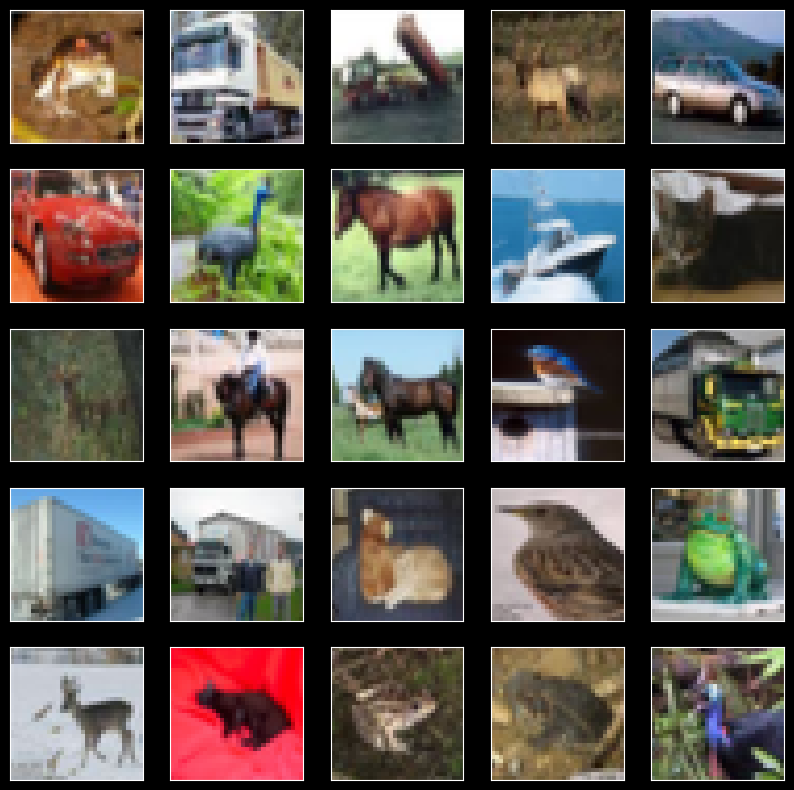

In [3]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
plt.show()

In [4]:
model = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/home/ilkka/anaconda3/envs/keras/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1774543452.061090    2328 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774543452.061660    2395 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774543452.081843    2328 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at http

In [5]:
history = model.fit(train_images, train_labels, epochs=10,
                    batch_size=64,
                    validation_data=(test_images, test_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.2716 - loss: 1.9747 - val_accuracy: 0.3467 - val_loss: 1.8101
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3306 - loss: 1.8402 - val_accuracy: 0.3845 - val_loss: 1.7338
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3532 - loss: 1.7767 - val_accuracy: 0.3987 - val_loss: 1.6647
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3682 - loss: 1.7424 - val_accuracy: 0.3892 - val_loss: 1.6803
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3796 - loss: 1.7160 - val_accuracy: 0.4019 - val_loss: 1.6727
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3860 - loss: 1.6979 - val_accuracy: 0.4321 - val_loss: 1.6073
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3942 - loss: 1.6814 - val_accuracy: 0.4229 - val_loss: 1.6191
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4002 - loss: 1.6627 - val_acc

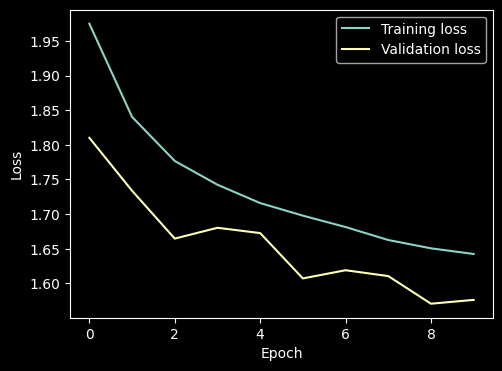

In [8]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

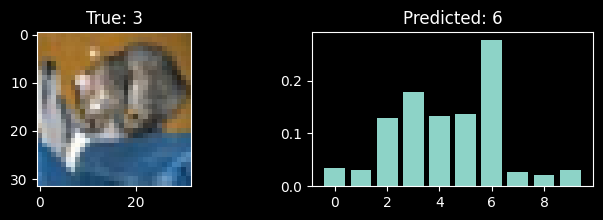

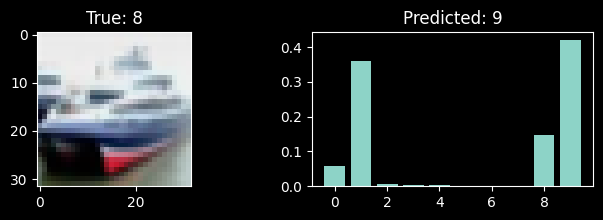

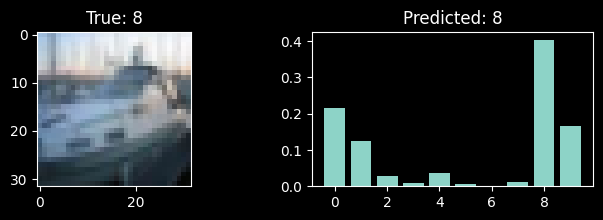

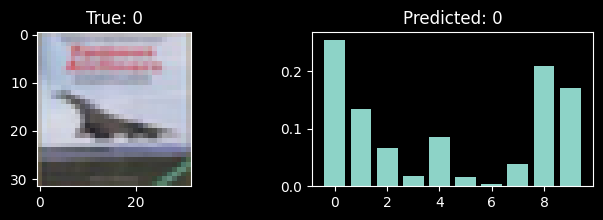

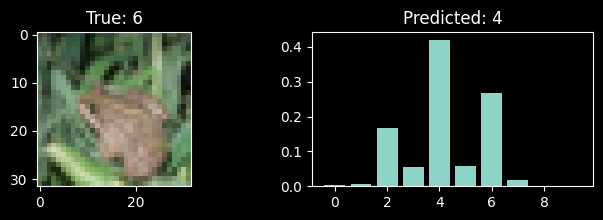

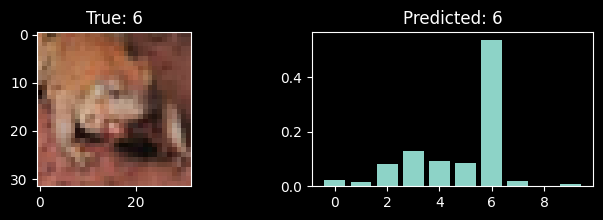

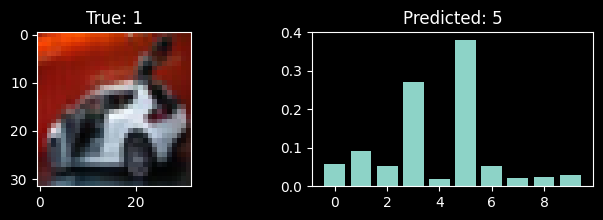

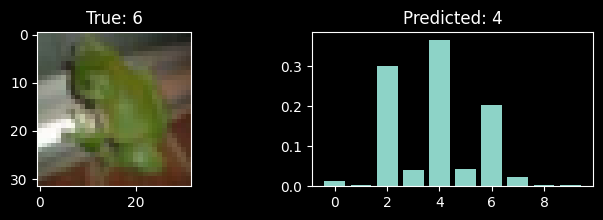

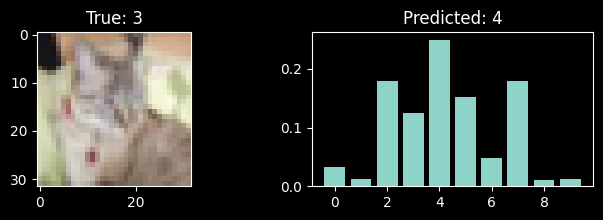

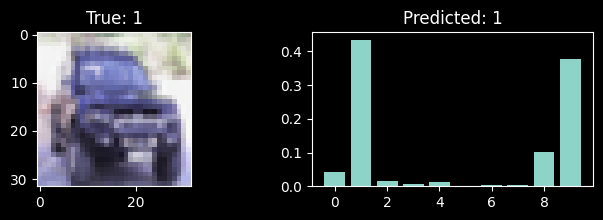

In [7]:
x = test_images
y = model(x)
start = 0

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1,2,1)
    plt.imshow(x[start+k])
    plt.title(f"True: {np.argmax(test_labels[start+k])}")
    plt.subplot(1,2,2)
    plt.bar(range(10), y[start+k])
    plt.title(f"Predicted: {np.argmax(y[start+k])}")
    plt.show()